# 1. The raw data

The COMSOL ensembles. Each row is one **disorder realization** — one random
placement of trapped charges at the SiGe/SiO₂ interface, solved for the resulting
double-quantum-dot parameters.

The device being simulated, and how each parameter is extracted from it, is
described in [`docs/device.md`](../docs/device.md).

| dataset | interface charge density | realizations |
|---|---|---|
| `rho5e9`  | 5×10⁹ cm⁻²  | 500 |
| `rho5e10` | 5×10¹⁰ cm⁻² | 500 |

In [1]:
import sys
from pathlib import Path

sys.path.insert(0, str(Path.cwd().parent))  # so `import chargetwin` works from notebooks/

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

import chargetwin as ct

In [2]:
for name, ds in ct.DATASETS.items():
    print(f"{name:9s}  rho = {ds.density:12s}  {ds.description}")

rho5e9     rho = 5e9 cm^-2     500 disorder realizations, low density, after tuning to the symmetric point.
rho5e10    rho = 5e10 cm^-2    500 disorder realizations, high density, after tuning to the symmetric point.


## Which parameters can I ask for?

`load_dataset` converts the raw COMSOL output into physical units and builds the
derived quantities — dot sizes from the confinement curvatures, sums and
differences between the left and right dot.

In [3]:
pd.DataFrame(ct.PARAMETERS).T[["unit", "desc"]]

,unit,desc
d,nm,Inter-dot distance
tc,ueV,Tunnel coupling
log2tc,log10(ueV),Log tunnel gap -- the Gaussian-friendly form o...
Lxavg,nm,Mean dot size along x
dLx,nm,Dot-size asymmetry along x
Lyavg,nm,Mean dot size along y
dLy,nm,Dot-size asymmetry along y
Favg,MV/m,Mean vertical electric field
dF,MV/m,Vertical-field asymmetry
eps,meV,Detuning at the tuned working point


## Pick the parameters you care about

`ct.PAPER_PARAMETERS` is the vector the paper models. Swap in anything from the
table above — everything downstream (models, plots, metrics) follows your choice.

Note the tunnel coupling enters as **`log2tc` = log₁₀(2t_c)**, not `tc`. Because
`t_c` depends exponentially on the inter-dot distance and barrier height (WKB),
its distribution has a long tail; a Gaussian fitted to raw `t_c` reproduces the
marginal badly *and* generates unphysical negative couplings. In log space it is
close to normal. Use `ct.add_tunnel_coupling(df)` to get `t_c` back in µeV.

In [4]:
PARAMS = ct.PAPER_PARAMETERS  # ["d", "log2tc", "Lxavg", "dLx", "Favg", "dF", "eps"]
DATASET = "rho5e10"

raw = ct.load_dataset(DATASET, PARAMS)
print(f"{len(raw)} realizations x {raw.shape[1]} parameters")
raw.head()

500 realizations x 7 parameters


,d,log2tc,Lxavg,dLx,Favg,dF,eps
0,75.933333,2.170041,21.925523,1.888496,5.269604,-0.032526,-3.555236
1,94.447795,1.424717,20.892351,-0.732536,5.295386,0.040632,-0.479219
2,97.178637,1.393891,20.967834,-1.484578,5.232523,0.041799,5.858150
3,87.128887,1.713228,21.016324,-0.058958,5.246750,0.051371,0.430473
4,107.679824,0.646883,19.565308,1.217709,5.267143,-0.048866,-3.287398


In [5]:
raw.describe().T[["mean", "std", "min", "max"]]

,mean,std,min,max
d,92.753278,11.230765,62.095060,123.069643
log2tc,1.392178,0.581424,-0.433157,2.493250
Lxavg,20.708743,0.837297,18.931273,23.263760
dLx,0.049067,0.761459,-2.281803,3.012334
Favg,5.267247,0.021919,5.206502,5.330742
dF,-0.001597,0.024950,-0.094319,0.069466
eps,0.036205,3.682990,-9.595409,11.216036


## Marginals

Most parameters sit in a tight, roughly Gaussian blob around their design value.
The tunnel coupling is the outlier: it swings over more than an order of
magnitude across nominally identical devices, and its distribution is strongly
skewed — which is exactly why we model it in log space.

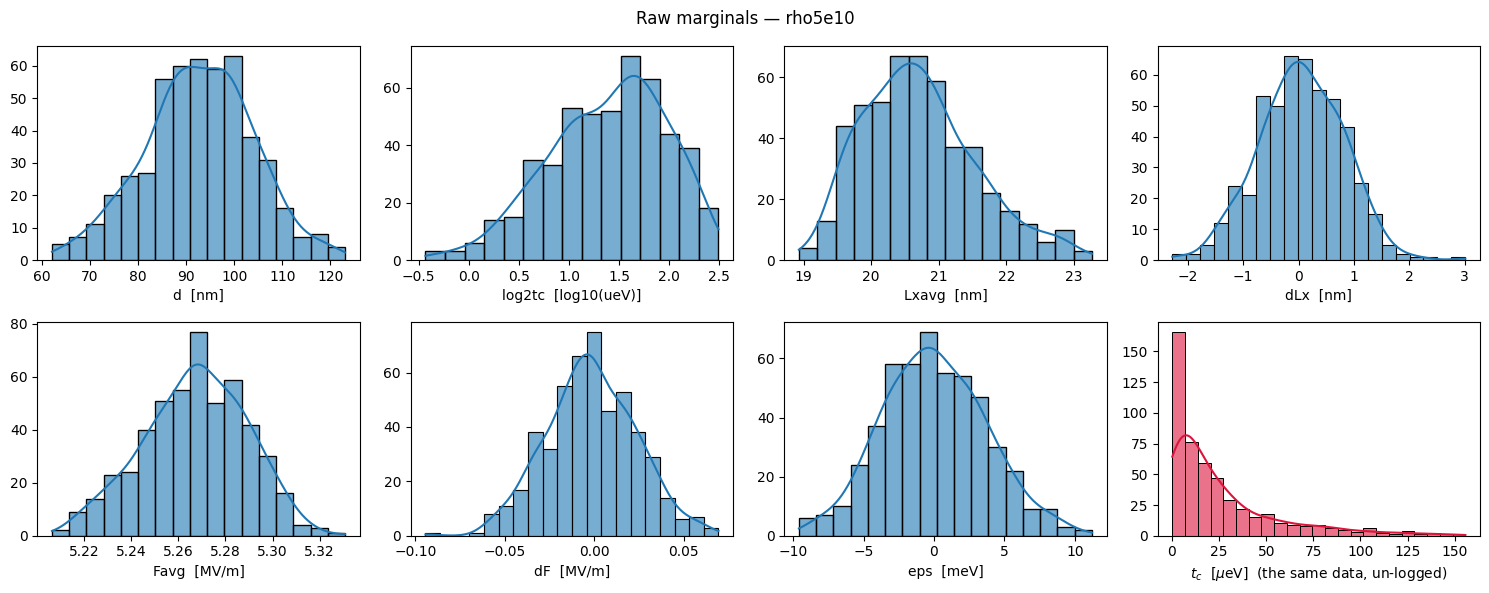

In [6]:
lin = ct.add_tunnel_coupling(raw)

fig, axes = plt.subplots(2, 4, figsize=(15, 6))
for ax, p in zip(axes.ravel(), PARAMS):
    sns.histplot(raw[p], ax=ax, kde=True, color="tab:blue", edgecolor="k", alpha=0.6)
    ax.set_xlabel(f"{p}  [{ct.PARAMETERS[p]['unit']}]")
    ax.set_ylabel("")

ax = axes.ravel()[len(PARAMS)]
sns.histplot(lin["tc"], ax=ax, kde=True, color="crimson", edgecolor="k", alpha=0.6)
ax.set_xlabel(r"$t_c$  [$\mu$eV]  (the same data, un-logged)")
ax.set_ylabel("")

fig.suptitle(f"Raw marginals — {DATASET}")
fig.tight_layout()

## Correlations

The parameters are **not** independent. Disorder that pushes the dots apart also
weakens the tunnel coupling and squeezes the confinement. Reproducing that
structure is the whole job of the generative models in notebook 2 — sampling each
parameter from its own histogram would throw it away.

Text(0.5, 1.0, 'Correlation matrix — rho5e10')

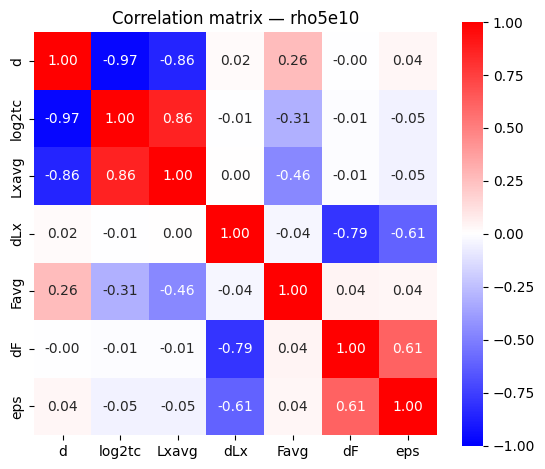

In [7]:
fig, ax = plt.subplots(figsize=(6.5, 5.5))
sns.heatmap(raw.corr(), cmap="bwr", vmin=-1, vmax=1, annot=True, fmt=".2f", square=True, ax=ax)
ax.set_title(f"Correlation matrix — {DATASET}")

## The effect of charge density

Ten times more interface charge widens every distribution. The correlation
structure survives largely intact — the disorder gets stronger, not different.

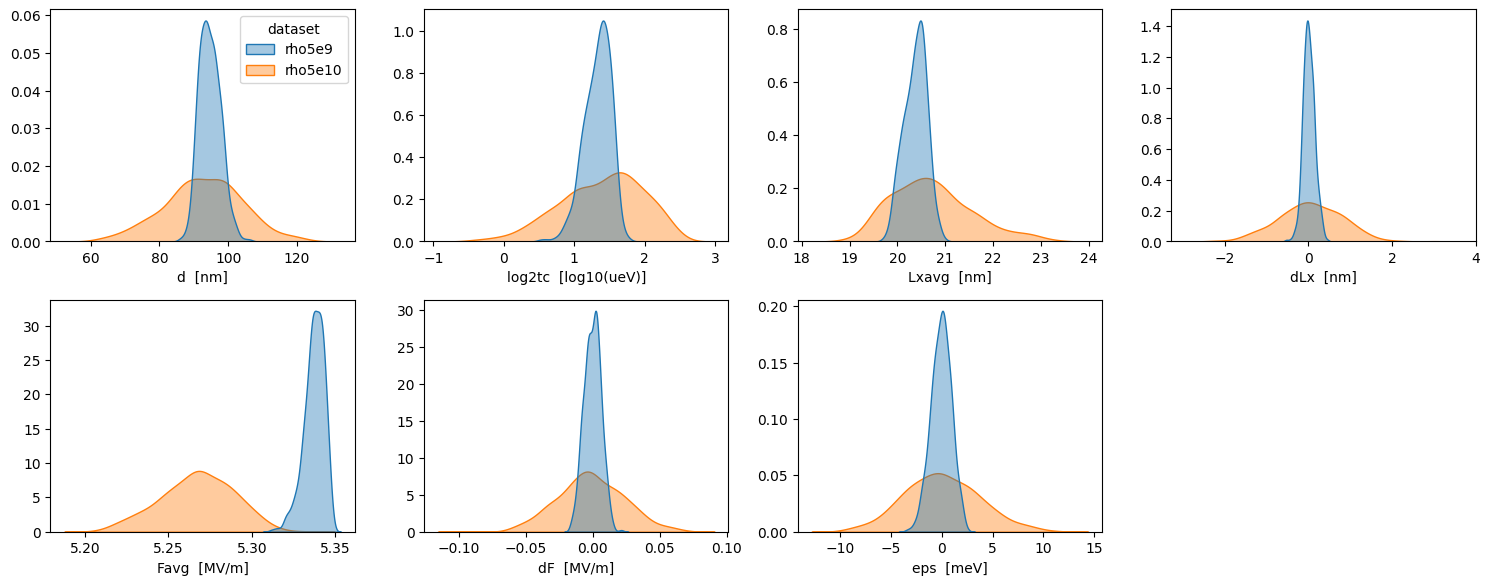

In [8]:
both = pd.concat([
    ct.load_dataset("rho5e9", PARAMS).assign(dataset="rho5e9"),
    ct.load_dataset("rho5e10", PARAMS).assign(dataset="rho5e10"),
])

fig, axes = plt.subplots(2, 4, figsize=(15, 6))
for ax, p in zip(axes.ravel(), PARAMS):
    sns.kdeplot(data=both, x=p, hue="dataset", fill=True, alpha=0.4, ax=ax, legend=(p == PARAMS[0]))
    ax.set_xlabel(f"{p}  [{ct.PARAMETERS[p]['unit']}]")
    ax.set_ylabel("")
for ax in axes.ravel()[len(PARAMS):]:
    ax.axis("off")
fig.tight_layout()

In [9]:
pd.DataFrame({
    ds: ct.load_dataset(ds, PARAMS).std() / ct.load_dataset(ds, PARAMS).mean().abs()
    for ds in ("rho5e9", "rho5e10")
}).rename_axis("coefficient of variation").round(3)

,rho5e9,rho5e10
coefficient of variation,,
d,0.033,0.121
log2tc,0.143,0.418
Lxavg,0.012,0.040
dLx,15.121,15.519
Favg,0.001,0.004
dF,14.691,15.620
eps,13.711,101.726


Next: **`02_models_and_validation.ipynb`** — compress this ensemble into a
generative model, and check that what comes out looks like what went in.